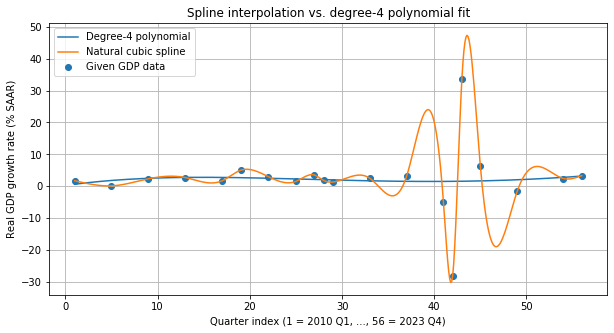

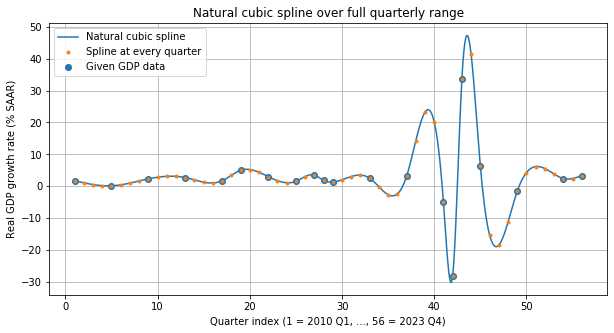

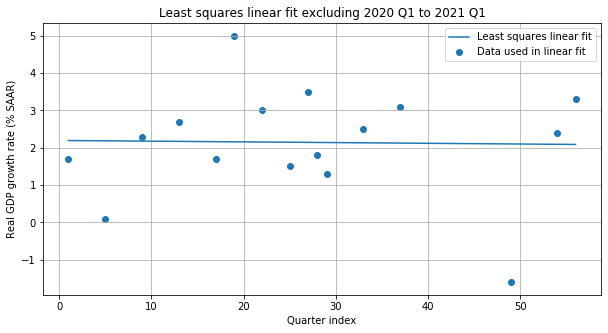

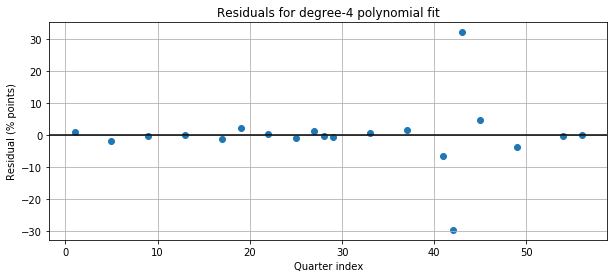

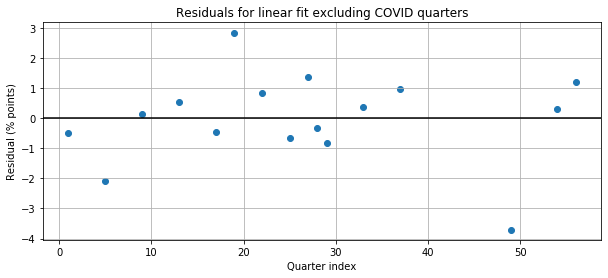

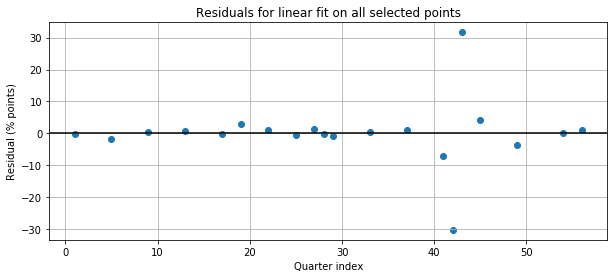

COE 311K GDP Project Numerical Summary
Number of given data points: 20
Quarter range used for full evaluation: 1 to 56

Natural cubic spline
  Unknown second derivatives in tridiagonal system: 18
  Tridiagonal matrix size: 18 x 18
  Max interpolation error at knots: 5.329071e-15
  Approx. max C1 jump near knots: 3.265083e-04
  Approx. max C2 jump near knots: 2.059184e-04
  Spline min on quarter grid: -28.1000
  Spline max on quarter grid: 41.3821

Degree-4 polynomial least squares
  Coefficients (ascending powers): [ 2.11403340e-01  4.12733208e-01 -2.11036921e-02  3.57892276e-04
 -1.71060095e-06]
  RMSE on given points: 10.0314
  cond(V): 1.8198e+07
  cond(V^T V): 3.3116e+14
  Max absolute residual: 32.2551

Least squares linear model excluding 2020 Q1 to 2021 Q1
  Intercept: 2.194285
  Slope: -0.001907 percentage points per quarter
  RMSE: 1.4432
  cond(A^T A): 3.6056e+03
  Max absolute residual: 3.7008

Least squares linear model on all selected points (diagnostic only)
  Intercept: 

,quarter_index,spline_value
0,1,1.700000
1,2,1.052550
2,3,0.504080
3,4,0.153570
4,5,0.100000
5,6,0.402745
6,7,0.962760
7,8,1.641395
8,9,2.300000
9,10,2.811471


In [34]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# GDP data from file, saved as (quarter,value)
DATA = [
    ("2010 Q1", 1.7),
    ("2011 Q1", 0.1),
    ("2012 Q1", 2.3),
    ("2013 Q1", 2.7),
    ("2014 Q1", 1.7),
    ("2014 Q3", 5.0),
    ("2015 Q2", 3.0),
    ("2016 Q1", 1.5),
    ("2016 Q3", 3.5),
    ("2016 Q4", 1.8),
    ("2017 Q1", 1.3),
    ("2018 Q1", 2.5),
    ("2019 Q1", 3.1),
    ("2020 Q1", -5.1),
    ("2020 Q2", -28.1),
    ("2020 Q3", 33.8),
    ("2021 Q1", 6.3),
    ("2022 Q1", -1.6),
    ("2023 Q2", 2.4),
    ("2023 Q4", 3.3),
]

#converts quarters to 1,2,3,4... basically converts quarter labels into numbers the math can use
#reference chatgpt: function to convert these quarters in integers for index
#this follows the instruction to use quarter indices as x-values
def quarter_to_index(label: str) -> int:
    year = int(label[:4])
    quarter = int(label[-1])
    return (year - 2010) * 4 + quarter


#puts the data in context with labels
#separates labels, x-values, and y-values so later functions are easier to use
#reference chatgpt: how to get rid of values when labeling just the quarters
def build_dataset():
    labels = [q for q, _ in DATA]
    x = np.array([quarter_to_index(q) for q, _ in DATA], dtype=float)  #builds the x array
    y = np.array([val for _, val in DATA], dtype=float)  #builds the y array
    return labels, x, y


#least squares linear fit
#used to find GDP trend, show slope, compare spline and polynomial
#reference chatgpt: how to make normal equations for least squares in python with matrix
def least_squares_linear(x, y):
    A = np.column_stack([np.ones(len(x)), x])  #builds matrix for y = a + bx
    ATA = A.T @ A
    ATy = A.T @ y

    coeffs = np.linalg.solve(ATA, ATy)  #solves normal equations
    yhat = A @ coeffs  #prediction values
    residuals = y - yhat
    rmse = np.sqrt(np.mean(residuals**2)) #reference chatgpt: how to compute rmse in python

    return {
        "A": A,
        "ATA": ATA,
        "ATy": ATy,
        "coeffs": coeffs,
        "yhat": yhat,
        "residuals": residuals,
        "rmse": rmse,
        "cond_ATA": np.linalg.cond(ATA),
    }


# Polynomial least squares
# best fit polynomial curve that doesnt pass every point
def polynomial_fit(x, y, degree):
    V = np.vander(x, N=degree + 1, increasing=True)  # polynomial matrix, reference chatgpt: function for polynomial matrix
    normal_matrix = V.T @ V  # normal equations
    rhs = V.T @ y

    coeffs = np.linalg.solve(normal_matrix, rhs)  #solves for polynomial coefficients
    yhat = V @ coeffs  #predicted values
    residuals = y - yhat
    rmse = np.sqrt(np.mean(residuals**2))

    return {
        "V": V,
        "normal_matrix": normal_matrix,
        "rhs": rhs,
        "coeffs": coeffs,
        "yhat": yhat,
        "residuals": residuals,
        "rmse": rmse,
        "cond_V": np.linalg.cond(V),
        "cond_normal": np.linalg.cond(normal_matrix),
    }


#computes the polynomial value
#this is used when plotting the polynomial smoothly
def evaluate_polynomial(coeffs, x):
    x = np.asarray(x, dtype=float)
    y = np.zeros_like(x)

    #refernce chatgpt: how build the polynomial one term at a time
    for power, c in enumerate(coeffs):
        y += c * x**power

    return y


#Natural cubic spline
#sets up system that solves for the spline second derivatives
def natural_cubic_spline_setup(x, y):
    n = len(x)
    if n < 3:
        raise ValueError #Need at least 3 points for a cubic spline
    h = np.diff(x)  # spacing between x-values
    if np.any(h <= 0):
        raise ValueError #x-values must be strictly increasing

    #tridiagonal system for natural cubic spline
    A = np.zeros((n - 2, n - 2))
    rhs = np.zeros(n - 2)

    #reference chatgpt: how do i build the tridiagonal matrix for natural cubic spline in python
    for i in range(1, n - 1):
        row = i - 1
        if row - 1 >= 0:
            A[row, row - 1] = h[i - 1]
        A[row, row] = 2 * (h[i - 1] + h[i])
        if row + 1 <= n - 3:
            A[row, row + 1] = h[i]

        # change in slope between intervals
        rhs[row] = 6 * ((y[i + 1] - y[i]) / h[i] - (y[i] - y[i - 1]) / h[i - 1])

    M = np.zeros(n)  # initializes second derivatives
    #endpoints stay 0
    M[1:n - 1] = np.linalg.solve(A, rhs)  #solving interior second derivatives

    return {
        "h": h,
        "A": A,
        "rhs": rhs,
        "M": M,
        "n_unknowns": n - 2,
    }

#reference chatgpt: how do i evulate a spline in python
#evaluates a spline at one or more x-values
#this uses the cubic spline formula on the correct interval
def evaluate_spline(x, y, h, M, x_eval):
    x_eval = np.atleast_1d(np.asarray(x_eval, dtype=float))  #ensures input is array
    out = np.zeros_like(x_eval)  #initializes output array for spline values

    #loops over each point we want
    for j, xe in enumerate(x_eval):
        if xe <= x[0]:
            i = 0
        elif xe >= x[-1]:
            i = len(x) - 2
        else:
            i = np.searchsorted(x, xe) - 1

        #interval endpoints and spacing
        xi = x[i]
        xi1 = x[i + 1]
        hi = h[i]

        #evaluate the spline formula on the interval
        out[j] = (
            M[i] * (xi1 - xe) ** 3 / (6 * hi)
            + M[i + 1] * (xe - xi) ** 3 / (6 * hi)
            + (y[i] - M[i] * hi**2 / 6) * (xi1 - xe) / hi
            + (y[i + 1] - M[i + 1] * hi**2 / 6) * (xe - xi) / hi
        )

    # return one value if one x was given otherwise return array
    if len(out) > 1:
        return out
    else:
        return out[0]


# computes first and second derivatives of the spline within given interval
# verifies continuity
def spline_interval_derivatives(x, y, h, M, interval_index, xe):
    i = interval_index
    xi = x[i]
    xi1 = x[i + 1]
    hi = h[i]
    #reference chatgpt: how do i compute the first derivative of spline
    #first derivative of spline
    first = (
        -M[i] * (xi1 - xe) ** 2 / (2 * hi)
        + M[i + 1] * (xe - xi) ** 2 / (2 * hi)
        - (y[i] - M[i] * hi**2 / 6) / hi
        + (y[i + 1] - M[i + 1] * hi**2 / 6) / hi
    )

    #second derivative of spline
    second = M[i] * (xi1 - xe) / hi + M[i + 1] * (xe - xi) / hi
    return first, second

#reference chatgpt: how do i verify the spline continuity and if its right
#checks if the spline matches the points and if derivatives line up smoothly
def verify_spline(x, y, h, M):
    point_error = np.max(np.abs(evaluate_spline(x, y, h, M, x) - y))  #function continuity
    eps = 1e-6
    max_c1_jump = 0.0  #slope continuity
    max_c2_jump = 0.0  #curve continuity

    for k in range(1, len(x) - 1):
        d1_left, d2_left = spline_interval_derivatives(x, y, h, M, k - 1, x[k] - eps)
        d1_right, d2_right = spline_interval_derivatives(x, y, h, M, k, x[k] + eps)

        max_c1_jump = max(max_c1_jump, abs(d1_left - d1_right))
        max_c2_jump = max(max_c2_jump, abs(d2_left - d2_right))

    return point_error, max_c1_jump, max_c2_jump

#Main workflow
labels, x, y = build_dataset()

#fit degree-4 polynomial
poly = polynomial_fit(x, y, degree=4)

#build natural cubic spline
spline = natural_cubic_spline_setup(x, y)

#exclude 2020 Q1 through 2021 Q1 for required linear model
covid_mask = ~((x >= 41) & (x <= 45))
x_no_covid = x[covid_mask]
y_no_covid = y[covid_mask]

linear_no_covid = least_squares_linear(x_no_covid, y_no_covid)

#diagnostic linear fit on all points
linear_all = least_squares_linear(x, y)

#verification values for spline
point_error, c1_jump, c2_jump = verify_spline(x, y, spline["h"], spline["M"])

#Plots
#Plot 1: spline vs polynomial
xf = np.linspace(1, 56, 500)
poly_vals = evaluate_polynomial(poly["coeffs"], xf)
spline_vals = evaluate_spline(x, y, spline["h"], spline["M"], xf)

plt.figure(figsize=(10, 5))
plt.scatter(x, y, label="Given GDP data")
plt.plot(xf, poly_vals, label="Degree-4 polynomial")
plt.plot(xf, spline_vals, label="Natural cubic spline")
plt.xlabel("Quarter index (1 = 2010 Q1, ..., 56 = 2023 Q4)")
plt.ylabel("Real GDP growth rate (% SAAR)")
plt.title("Spline interpolation vs. degree-4 polynomial fit")
plt.legend()
plt.grid(True)
plt.show()

#Plot 2: spline over full quarterly range
quarter_grid = np.arange(1, 57)
quarter_values = evaluate_spline(x, y, spline["h"], spline["M"], quarter_grid)

plt.figure(figsize=(10, 5))
plt.scatter(x, y, label="Given GDP data")
plt.plot(xf, spline_vals, label="Natural cubic spline")
plt.plot(quarter_grid, quarter_values, "o", markersize=3, label="Spline at every quarter")
plt.xlabel("Quarter index (1 = 2010 Q1, ..., 56 = 2023 Q4)")
plt.ylabel("Real GDP growth rate (% SAAR)")
plt.title("Natural cubic spline over full quarterly range")
plt.legend()
plt.grid(True)
plt.show()

#Plot 3: linear fit excluding COVID
xs = np.linspace(x_no_covid.min(), x_no_covid.max(), 200)
ys = linear_no_covid["coeffs"][0] + linear_no_covid["coeffs"][1] * xs

plt.figure(figsize=(10, 5))
plt.scatter(x_no_covid, y_no_covid, label="Data used in linear fit")
plt.plot(xs, ys, label="Least squares linear fit")
plt.xlabel("Quarter index")
plt.ylabel("Real GDP growth rate (% SAAR)")
plt.title("Least squares linear fit excluding 2020 Q1 to 2021 Q1")
plt.legend()
plt.grid(True)
plt.show()


#Plot 4: residuals for polynomial fit
plt.figure(figsize=(10, 4))
plt.axhline(0, color="black")
plt.scatter(x, poly["residuals"])
plt.xlabel("Quarter index")
plt.ylabel("Residual (% points)")
plt.title("Residuals for degree-4 polynomial fit")
plt.grid(True)
plt.show()


#Plot 5: residuals for linear fit excluding COVID
plt.figure(figsize=(10, 4))
plt.axhline(0, color="black")
plt.scatter(x_no_covid, linear_no_covid["residuals"])
plt.xlabel("Quarter index")
plt.ylabel("Residual (% points)")
plt.title("Residuals for linear fit excluding COVID quarters")
plt.grid(True)
plt.show()


#Plot 6: residuals for linear fit on all selected points
plt.figure(figsize=(10, 4))
plt.axhline(0, color="black")
plt.scatter(x, linear_all["residuals"])
plt.xlabel("Quarter index")
plt.ylabel("Residual (% points)")
plt.title("Residuals for linear fit on all selected points")
plt.grid(True)
plt.show()


#summary
#reference chatgpt: here is my instructions, gimme a checklist of what i should include in summary
print("COE 311K GDP Project Numerical Summary")
print(f"Number of given data points: {len(x)}")
print("Quarter range used for full evaluation: 1 to 56")
print()

print("Natural cubic spline")
print(f"  Unknown second derivatives in tridiagonal system: {spline['n_unknowns']}")
print(f"  Tridiagonal matrix size: {spline['A'].shape[0]} x {spline['A'].shape[1]}")
print(f"  Max interpolation error at knots: {point_error:.6e}")
print(f"  Approx. max C1 jump near knots: {c1_jump:.6e}")
print(f"  Approx. max C2 jump near knots: {c2_jump:.6e}")
print(f"  Spline min on quarter grid: {quarter_values.min():.4f}")
print(f"  Spline max on quarter grid: {quarter_values.max():.4f}")
print()

print("Degree-4 polynomial least squares")
print(f"  Coefficients (ascending powers): {poly['coeffs']}")
print(f"  RMSE on given points: {poly['rmse']:.4f}")
print(f"  cond(V): {poly['cond_V']:.4e}")
print(f"  cond(V^T V): {poly['cond_normal']:.4e}")
print(f"  Max absolute residual: {np.max(np.abs(poly['residuals'])):.4f}")
print()

print("Least squares linear model excluding 2020 Q1 to 2021 Q1")
print(f"  Intercept: {linear_no_covid['coeffs'][0]:.6f}")
print(f"  Slope: {linear_no_covid['coeffs'][1]:.6f} percentage points per quarter")
print(f"  RMSE: {linear_no_covid['rmse']:.4f}")
print(f"  cond(A^T A): {linear_no_covid['cond_ATA']:.4e}")
print(f"  Max absolute residual: {np.max(np.abs(linear_no_covid['residuals'])):.4f}")
print()

print("Least squares linear model on all selected points (diagnostic only)")
print(f"  Intercept: {linear_all['coeffs'][0]:.6f}")
print(f"  Slope: {linear_all['coeffs'][1]:.6f} percentage points per quarter")
print(f"  RMSE: {linear_all['rmse']:.4f}")
print()

#show quarter by quarter spline table
spline_table = pd.DataFrame({
    "quarter_index": quarter_grid.astype(int),
    "spline_value": quarter_values
})

print("Spline values at every quarter from 2010 Q1 to 2023 Q4:")
display(spline_table)

In [37]:
""""Introduction:

In this project I analyzed the quarterly US GDP from 2010 Q1 to 2023 Q4. 
The dataset shows the economic output over the time period and reflects the deviations that took place during 
the COVID-19 era. Three methods were applied to model and analyze the data which include cubic spline interpolation, 
least-squares polynomial approximation, and linear regression. All of three of these were assessed in terms of accuracy, 
sensitivity to outliers, numerical stability, and the smoothness. The purpose was to determine which method is the 
most appropriate for interpolation and which is best suited for long term economic trends.

Part A: 

Cubic Spline Interpolation
The GDP dataset was interpolated using a natural cubic spline. Piecewise cubic polynomials formed between each pair 
of repeated data points make up the spline. A system of equations based on the second derivatives at the inner knots 
was created in order to find the spline. There are 18 inner knots and 18 unknown second derivatives because there are 
20 data points. Both the first and second derivatives continuity and the function's continuity at each knot are maintained
by the system. Furthermore, the second derivatives at the endpoints are set to zero in order to apply natural boundary 
conditions. The spline is specific by these constraints, which lead to a tridiagonal linear system that was numerically 
solved.

Values were assessed at all 55 quarterly points between 2010 Q1 and 2023 Q4 using the constructed spline. This was done 
through calculating the 20 given date points through which we were able to predict the 55 points. A smooth curve 
that closely tracks the data across the whole interval is displayed in the final plot. There are no sudden oscillations or 
discontinuities, and the spline seems visually natural and smooth as shown in the figure below. This behavior demonstrates
that the approach effectively captures both localized changes and atypical trends in the data. Quantitatively, the spline 
confirms accurate interpolation at the data points with a maximum interpolation error of 5.33 × 10−15. The spline is smooth 
with continuous first and second derivatives across all knots, as indicated by the approximate C¹ and C² discontinuities of 
3.27 × 10−4 and 2.06 × 10−4 respectively.

Because cubic splines interpolate all data points exactly, the spline passes accurately through the extreme value observed 
in 2020 Q2, where GDP experienced a sharp decline of −28.1%. This guarantees correct interpolation, but it also highlights
the trade-off between numerical stability and exact interpolation. Extreme outliers have the ability to locally alter the 
spline's shape and possibly affect surrounding intervals. The spline achieves a maximum value of roughly 41.38% soon after 
the −28.1% shrinkage in 2020 Q2, illustrating how severe data points can cause significant local oscillations even in 
spline interpolation. 

The more general problem of sensitivity in interpolation methods is connected to this occurrence. On the other hand, 
especially close to an interval's endpoints, high-degree polynomial interpolation may display oscillating behavior 
known as the Runge phenomenon. Cubic splines use piecewise polynomials to address this problem, but they still precisely 
fit all data points, including outliers. Smoothing splines and weighted least-squares techniques may be better for 
datasets with extreme values because they lessen the impact of outliers and offer a more stable overall fit.

Part B: 

Polynomial & Least Squares Comparison
Using the least-squares approach, a degree-4 polynomial was fitted to the GDP data and shown next to the cubic spline. 
Although it does not pass through every data point, the polynomial offers a smooth global approximation of the data. 
The cubic spline, on the other hand, precisely interpolates every point. When comparing the two models, the spline does a 
better job of reproducing certain data values, especially during times of abrupt change like the COVID-19 slump. Extreme 
deviations are not adequately captured by the polynomial fit, which smoothes out these localized changes. The degree-4 
polynomial fit quantitatively shows a poor fit to the data, especially during times of significant economic change, 
with an RMSE of 10.03 and a maximum absolute residual of 32.26 percentage points.

The polynomial 's residual plot as shown in the figure below exhibits visible structure as opposed to random scatter, 
suggesting that the model falls short of accurately capturing the data's underlying behavior. The magnitude of the residuals, 
which surpass 30 percentage points close to the COVID era, provides more evidence that the polynomial model is unable to 
account for significant local fluctuations in the data. Larger residuals, in particular, show that the polynomial has 
trouble with localized variation close to times of fast economic change. Furthermore, the matrix V^T V's condition number 
is almost 10^14, indicating extreme poor conditions. This shows that the model is numerically unstable since the calculated 
coefficients are extremely sensitive to even little changes in the data. A linear least-squares model was also constructed 
using data that excludes the COVID-19 period from 2020 Q1 through 2021 Q1 as shown below. The calculated slope is slightly 
negative (−0.0019 percentage points per quarter), indicating an approximately flat or marginally declining long-term trend, 
suggesting consistent long-term economic expansion. The linear model's residual plot, however, exhibits an ongoing variance 
from zero, indicating the model's failure to account for nonlinear patterns. The linear model achieves an RMSE of 1.44 and 
a maximum residual of 3.70, showing improved stability compared to the polynomial fit, although it still fails to capture 
nonlinear fluctuations in the data.This demonstrates that even though the linear model is straightforward and easy to 
understand, it falls short in capturing the intricacy of the data. 

Part C: 

Method Justification
Cubic spline interpolation is the best technique for a policymaker looking to estimate GDP growth between two known data 
points. By precisely matching the known data points and preserving smoothness through continuous first and second 
derivatives, the spline gives an accurate approximation. This guarantees a consistent and realistic interpolation of 
intermediate values. Quantitative evidence also supports this conclusion: the spline achieves nearly zero interpolation 
error (5.33×10−15), the polynomial model has an RMSE of 10.03 and a maximum residual of 32.26, and the linear model, 
while more stable (RMSE 1.44), fails to capture nonlinear behavior.

Polynomial fitting's sensitivity to numerical instability and incapacity to adjust to local fluctuations make 
it less appropriate for interpolation. The polynomial model's high condition number suggests that it is unreliable for 
accurate estimates. Furthermore, because polynomial models are global in nature, one outlier may have an impact on the fit 
as a whole.

By employing a piecewise construction, the cubic spline overcomes these problems and maintains smoothness while adapting 
locally. This effect is limited rather than global, even though it is still susceptible to severe outliers. The use of 
cubic splines for precise interpolation is further supported quantitatively by the structured residuals seen in 
least-squares fits and the instability of the polynomial model, as shown by its huge condition number. The spline is the 
recommended interpolation technique in this situation because it generally strikes a better balance between accuracy, 
smoothness, and stability.

Big-O notation explains how an algorithm's runtime increases with the size (n) of the input. It examines the main term 
that governs the algorithm's scaling rather than precise timing. This makes it helpful for broadly comparing various 
approaches, particularly as datasets grow in size.

The algorithm for this project's linear least-squares model loops through the GDP data once to calculate sums like 
∑𝑥𝑖, ∑𝑦𝑖, and ∑𝑥𝑖𝑦i. This results in a temporal complexity of 𝑂(𝑛). The total complexity stays 𝑂(𝑛) since solving the 
resulting 2×2 system takes constant time.

The algorithm calculates higher powers of x and associated sums for the degree-4 polynomial least-squares model. 
This is also O(n) because it only needs one loop through the data because the degree (4) is fixed. The resulting 
5x5 system can be solved in constant time. The project findings show that this model performed badly and 
had a high condition number particularly when the COVID-affected data was included.

The approach calculates interval widths for the natural cubic spline and finds the spline coefficients by solving 
a tridiagonal linear problem. This system takes O(n) time to form and solve. Spline evaluation is effective in capturing 
changes between data points, even the abrupt changes that occurred during the COVID period.

The Big-O analysis does not alter my recommendation because time complexity of all three approaches is O(n). 
For this dataset, their computational efficiency is about equal, therefore accuracy and stability should be the 
deciding factors. Because it delivers a smooth, reliable interpolation and adjusts to local changes in the GDP data, 
the cubic spline worked best in this project. The linear model yielded a virtually flat or slightly negative slope, 
which fails to capture the underlying variability of the data. The polynomial model was less stable and susceptible 
to the COVID outliers especially when COVID quarters were excluded.Therefore, even after considering Big-O complexity, 
I would still use the natural cubic spline, and the complexity analysis supports the original conclusion rather than 
changing it.

Conclusion:

In order to simulate GDP data, this project contrasted cubic spline interpolation, polynomial approximation, and linear 
regression. For interpolation, the cubic spline worked best since it maintained numerical stability while giving an 
accurate and smooth representation of the data. The polynomial model was constrained by significant ill-conditioning and 
decreased reliability, despite its capacity to capture broad trends. While the linear model provided a straightforward 
depiction of long-term growth, it was unable to account for short-term oscillations and nonlinear behavior. These findings 
emphasize how crucial it is to choose the right numerical techniques depending on the data's properties and the analysis's 
objectives, since many approaches include trade-offs between precision, stability, and adaptability.
"""

'"Introduction:\n\nIn this project I analyzed the quarterly US GDP from 2010 Q1 to 2023 Q4. \nThe dataset shows the economic output over the time period and reflects the deviations that took place during \nthe COVID-19 era. Three methods were applied to model and analyze the data which include cubic spline interpolation, \nleast-squares polynomial approximation, and linear regression. All of three of these were assessed in terms of accuracy, \nsensitivity to outliers, numerical stability, and the smoothness. The purpose was to determine which method is the \nmost appropriate for interpolation and which is best suited for long term economic trends.\n\nPart A: \n\nCubic Spline Interpolation\nThe GDP dataset was interpolated using a natural cubic spline. Piecewise cubic polynomials formed between each pair \nof repeated data points make up the spline. A system of equations based on the second derivatives at the inner knots \nwas created in order to find the spline. There are 18 inner knot